# Lab: Uniswap V2 AMM — Implementation & Analysis

**Prerequisites:** Python 3.10+, `matplotlib`, `numpy`  
**Estimated time:** 2 hours

---

## Introduction

Most DeFi protocols are built on top of one core primitive: the **Automated Market Maker (AMM)**. Instead of matching buyers and sellers through an order book, an AMM uses a mathematical formula to determine prices algorithmically.

Uniswap V2 uses the **constant product formula**:

$$x \cdot y = k$$

Where `x` and `y` are the reserves of two tokens in a pool, and `k` is a constant that must hold after every trade (accounting for fees). This deceptively simple equation encodes all the pool's behavior: pricing, slippage, liquidity incentives.

In this lab you will:
1. Implement a working AMM pool from scratch
2. Analyze how trade size affects price
3. Model liquidity provision and fee accrual

In [2]:
import math
import random

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

---

## Part 1 — Pool Mechanics

### 1.1 The `UniswapV2Pool` Class

Implement the pool. The constructor takes initial reserves and a fee in **basis points** (1 bps = 0.01%, so the default 30 bps = 0.3%).

**Task 1.1** — Implement all properties. Verify with a sanity check: pool with `reserve_x=1000, reserve_y=2_000_000` should have `price = 2000.0` and `k = 2_000_000_000`.

In [7]:
class UniswapV2Pool:
    def __init__(self, reserve_x: float, reserve_y: float, fee_bps: int = 30):
        self.reserve_x = reserve_x
        self.reserve_y = reserve_y
        self.fee_bps = fee_bps
        self.total_shares = 0.0
        self.lp_positions = {}
        self.lp_entry_k = {}

    @property
    def k(self) -> float:
        """Constant product invariant x * y."""
        return self.reserve_x * self.reserve_y

    @property
    def price(self) -> float:
        """Spot price of X denominated in Y (e.g. ETH price in USDC)."""
        return self.reserve_y / self.reserve_x

    @property
    def fee_rate(self) -> float:
        """Fee as a decimal fraction (e.g. 0.003 for 30 bps)."""
        return self.fee_bps / 10000

    def __repr__(self) -> str:
        # TODO: return a string showing reserve_x, reserve_y, price, and k
        return f"UniswapV2Pool({self.reserve_x}, {self.reserve_y}, {self.fee_bps})"

    # ----- Methods below will be implemented in later tasks -----

    def get_amount_out(self, amount_in: float, token: str) -> float:
        """
        Pure calculation — does NOT change state.
        token='x' means selling X to receive Y, and vice versa.
        """
        assert token in ('x', 'y'), "token must be 'x' or 'y'"

        # TODO (Task 1.2): select reserve_in and reserve_out based on token direction
        # TODO: apply the fee to amount_in
        # TODO: compute amount_out using the constant product formula
        # TODO: return amount_out
        if token == "x":
          reserve_in, reserve_out = self.reserve_x, self.reserve_y
        else:
          reserve_in, reserve_out = self.reserve_y, self.reserve_x

        amount_in_with_fee = amount_in * (1 - self.fee_rate)
        amount_out = (reserve_out * amount_in_with_fee) / (reserve_in + amount_in_with_fee)
        return amount_out

    def swap(self, amount_in: float, token: str) -> float:
        """
        Executes a swap. Updates reserves and returns amount_out.
        """
        k_before = self.k
        amount_out = self.get_amount_out(amount_in, token)

        # TODO (Task 1.3): update reserve_x and reserve_y depending on token direction
        #       selling X: reserve_x increases, reserve_y decreases
        #       selling Y: reserve_y increases, reserve_x decreases
        if token == "x":
          self.reserve_x += amount_in
          self.reserve_y -= amount_out
        else:
          self.reserve_y += amount_in
          self.reserve_x -= amount_out

        # TODO: assert that k has not decreased after the swap
        #       (it may increase slightly — think about why)
        assert self.k >= k_before, "k decreased after swap"

        return amount_out

    def add_liquidity(self, amount_x: float, amount_y: float, provider: str) -> float:
        """
        Adds liquidity. For the first deposit uses sqrt(x * y).
        For subsequent deposits, adjusts amount_y to match the current ratio.
        Returns number of shares minted.
        """
        if self.total_shares == 0:
            # TODO (Task 3.1): first deposit
            #   - set reserve_x = amount_x, reserve_y = amount_y
            #   - set shares = sqrt(amount_x * amount_y)
            pass
        else:
            # TODO: subsequent deposit
            #   - compute the correct amount_y to match current ratio:
            #     amount_y = amount_x * (reserve_y / reserve_x)
            #   - compute shares = (amount_x / reserve_x) * total_shares
            #   - update reserve_x and reserve_y
            pass

        # TODO: update total_shares
        # TODO: add shares to lp_positions[provider] (initialize to 0 if new)
        # TODO: store current k in lp_entry_k[provider] for fee tracking
        # TODO: return shares minted
        pass

    def remove_liquidity(self, shares: float, provider: str) -> tuple[float, float]:
        """
        Burns shares and returns (amount_x, amount_y) to the provider.
        """
        assert provider in self.lp_positions, "Unknown provider"
        assert self.lp_positions[provider] >= shares, "Insufficient shares"

        # TODO (Task 3.2): compute ownership fraction = shares / total_shares
        # TODO: compute amount_x = ownership * reserve_x (and same for y)
        # TODO: decrease reserve_x, reserve_y, total_shares, lp_positions[provider]
        # TODO: return (amount_x, amount_y)
        pass

    def fees_earned(self, provider: str) -> dict:
        """
        Estimates fees earned since deposit based on k growth.
        Returns a dict with deposit_x, deposit_y, current_x, current_y, fee_x, fee_y.
        """
        assert provider in self.lp_positions

        # TODO (Task 3.3): compute ownership fraction
        # TODO: compute current_x = ownership * reserve_x (and same for y)
        # TODO: compute k_ratio = sqrt(k / lp_entry_k[provider])
        # TODO: back-compute deposit_x = current_x / k_ratio (and same for y)
        # TODO: fee_x = current_x - deposit_x, fee_y = current_y - deposit_y
        # TODO: return dict with all six values
        pass

#### Sanity check — Task 1.1

Create a pool with `reserve_x=1000, reserve_y=2_000_000` and verify `price == 2000.0` and `k == 2_000_000_000`.

In [4]:
# TODO: create pool and print price, k, and the pool repr
pool = UniswapV2Pool(reserve_x=1000, reserve_y=2_000_000)
print(f"Price: {pool.price}")
print(f"k: {pool.k}")
print(pool)

Price: 2000.0
k: 2000000000
UniswapV2Pool(1000, 2000000, 30)


---

### 1.2 Computing `get_amount_out`

The formula accounts for the fee taken on the input side:

$$\text{amount\_in\_with\_fee} = \text{amount\_in} \times (1 - \text{fee\_rate})$$

$$\text{amount\_out} = \frac{\text{reserve\_out} \times \text{amount\_in\_with\_fee}}{\text{reserve\_in} + \text{amount\_in\_with\_fee}}$$

This is derived directly from $x \cdot y = k$ — solve for the new reserve after the swap, take the difference. The fee is *not* returned to the sender; it stays in the pool.

**Task 1.2** — Go back to the class cell above and implement `get_amount_out`. Then verify by hand: pool is `100 X / 100 Y` (price = 1.0), fee = 0%, swap 10 X. You should receive exactly `9.09...` Y, not 10. Why?

Even with 0% fee, adding 10 X to a 100/100 pool doesn't give 10 Y back. The pool must keep k = 100*100 = 10000. After: new_x = 110, so new_y = 10000/110 ≈ 90.91. You get 100 - 90.91 ≈ 9.09 Y.

In [6]:
# TODO: create a pool with 100 X / 100 Y, fee_bps=0
# TODO: compute get_amount_out(10, 'x') and verify it equals ~9.0909
# TODO: explain in a comment why the output is less than 10
pool = UniswapV2Pool(reserve_x=100, reserve_y=100, fee_bps=0)
print(pool.get_amount_out(10, 'x'))

9.090909090909092


---

### 1.3 Executing a Swap

**Task 1.3** — Go back to the class cell above and implement `swap`. Then run 1000 random swaps and assert `k` never decreases. Print `k` before and after the full run — does it grow? Why does it sometimes *increase*? Where do the fees go?

In [15]:
# TODO: create a pool (e.g. 1000 X / 2_000_000 Y)
# TODO: record k_initial
# TODO: run 1000 random swaps (random token, random amount up to 2% of reserve)
# TODO: assert k never decreases after each swap
# TODO: print k_initial and k_final
import random

pool = UniswapV2Pool(reserve_x=1000, reserve_y=2_000_000)
k_initial = pool.k
for _ in range(1000):
  token = random.choice(["x", "y"])
  if token == "x":
    amount = random.uniform(0, pool.reserve_x * 0.02)
  else:
    amount = random.uniform(0, pool.reserve_y * 0.02)
  pool.swap(amount, token)

assert pool.k >= k_initial, "k increased after swap"
print(f"k_initial: {k_initial}")
print(f"k_final: {pool.k}")

k_initial: 2000000000
k_final: 2060013330.585011


*Your explanation (why does k grow?):*

YOUR ANSWER HERE

k grows because the swap fee is subtracted from amount_in when computing amount_out, but the full amount_in is added to the reserve. That small extra amount stays in the pool, so k = reserve_x * reserve_y increases with every trade.

---

## Part 2 — Price Impact

Price impact is the difference between the price you *expected* (spot price before the trade) and the price you *actually got* (execution price).

$$\text{price\_impact} = \frac{p_{\text{spot}} - p_{\text{execution}}}{p_{\text{spot}}}$$

For a swap X → Y:
- Spot price: `reserve_y / reserve_x`
- Execution price: `amount_out / amount_in`

### 2.1 Single Swap Analysis

**Task 2.1** — Compute spot price, execution price, and price impact for `amount_in = 1, 10, 50, 100` ETH. Fill in the table below.

In [17]:
pool = UniswapV2Pool(reserve_x=1000, reserve_y=2_000_000)  # 1 ETH = 2000 USDC

# TODO: for each amount_in in [1, 10, 50, 100]:
#   - compute spot_price from pool
#   - compute amount_out using get_amount_out (do NOT call swap)
#   - compute execution price = amount_out / amount_in
#   - compute price_impact
#   - print all values in a readable format
print(f"{'Amount In':>12}| {'Spot Price':>10} | {'Exec Price':>10} | {'Impact':>8}")
print("-" * 30)

for amount_in in [1, 10, 50, 100]:
  spot_price = pool.price
  amount_out = pool.get_amount_out(amount_in, "x")
  execution_price = amount_out / amount_in
  price_impact = (spot_price - execution_price) / spot_price

  print(f"{amount_in:>12} | {spot_price:>10.2f} | {execution_price:>8.2f} | {price_impact:>7.4%}")

   Amount In| Spot Price | Exec Price |   Impact
------------------------------
           1 |    2000.00 |  1992.01 | 0.3993%
          10 |    2000.00 |  1974.32 | 1.2842%
          50 |    2000.00 |  1899.32 | 5.0341%
         100 |    2000.00 |  1813.22 | 9.3389%


**Fill in the table:**

| Amount In (ETH) | Spot Price | Exec Price | Price Impact |
|---|---|---|---|
| 1 | 2000.0|1992.01 | 0.3993%|
| 10 | 2000.0| 1974.32|1.2842% |
| 50 | 2000.0| 1899.32|5.0341% |
| 100 | 2000.0| 1813.22|9.3389% |

---

### 2.2 Experiment: Swap Size vs Price Impact

Sweep `amount_in` from 0.1 ETH to 500 ETH and plot the price impact curve.

**Task 2.2** — Create the plot with:
- Price impact (%) on y-axis vs trade size as % of `reserve_x` on x-axis
- Horizontal dashed lines at 1% and 5% impact
- Axis labels, title, legend, grid

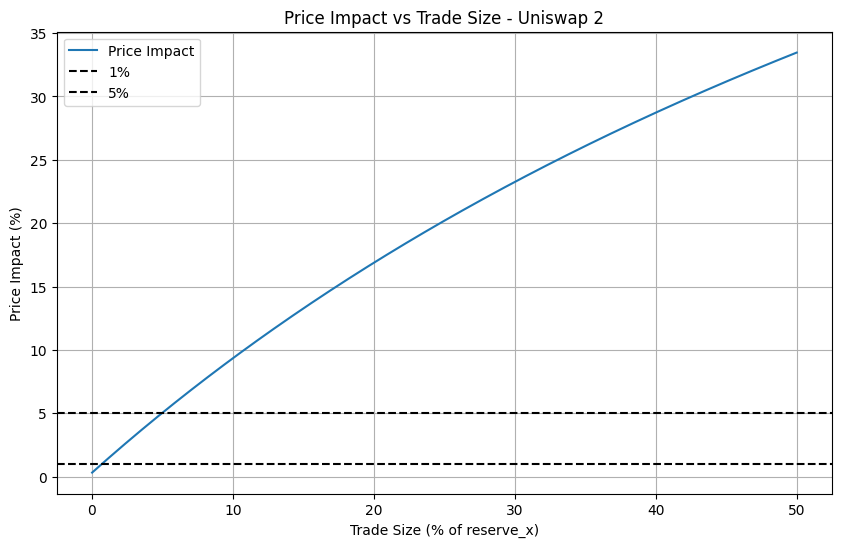

In [19]:
pool = UniswapV2Pool(reserve_x=1000, reserve_y=2_000_000)
sizes = np.linspace(0.1, 500, 300)

# TODO: for each size in sizes:
#   - compute execution price via get_amount_out (no state change)
#   - compute price impact
#   - collect into a list
impacts = []
for size in sizes:
  spot = pool.price
  amount_out = pool.get_amount_out(size, "x")
  execution_price = amount_out / size
  impact = (spot - execution_price) / spot * 100
  impacts.append(impact)
trade_pct = sizes / pool.reserve_x * 100
# TODO: plot price impact (%) on y-axis vs trade size as % of reserve_x on x-axis
# TODO: add horizontal dashed lines at 1% and 5% impact
# TODO: add axis labels, title, legend, grid
plt.figure()
plt.plot(trade_pct, impacts, label="Price Impact")
plt.axhline(1, color="black", linestyle="--", label="1%")
plt.axhline(5, color="black", linestyle="--", label="5%")
plt.xlabel("Trade Size (% of reserve_x)")
plt.ylabel("Price Impact (%)")
plt.title("Price Impact vs Trade Size - Uniswap 2")
plt.legend()
plt.grid(True)
plt.show()

**Research questions (Task 2.2):**
- At what trade size (as % of pool) does price impact cross 1%? Cross 5%?
- Is the curve linear or convex? Explain why from the formula.
- At 10% of pool size, what is the approximate impact? Is this acceptable for a DEX user?

YOUR ANSWER HERE

About 0.5% to cross 1%
About 2.5% to cross 5%

The line is curvex, as it is illustrated it curves upward. The formula indicates that it is a rational function, that's why the curve is convex.

---

### 2.3 Experiment: Pool Depth vs Price Impact

Fix the trade at \$10,000. Vary pool TVL from \$100k to \$100M and observe how pool depth affects price.

**Task 2.3** — Create the plot with:
- Price impact (%) on y-axis vs TVL (\$) on x-axis with log scale on x
- Horizontal dashed lines at 0.1% and 1.0%
- Axis labels, title, legend, grid

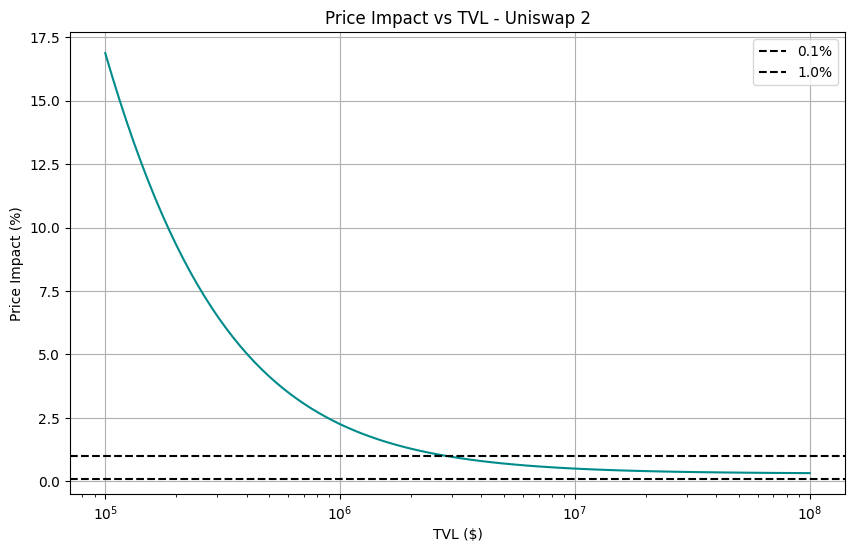

In [24]:
trade_size_usd = 10_000
price_eth = 2000
tvl_values = np.logspace(5, 8, 100)  # $100k -> $100M on log scale

# TODO: for each tvl in tvl_values:
#   - split 50/50: reserve_y = tvl/2 in USDC, reserve_x = reserve_y / price_eth in ETH
#   - create a fresh UniswapV2Pool
#   - compute amount_in in ETH = trade_size_usd / price_eth
#   - compute price impact
#   - collect into a list
impacts = []
for tvl in tvl_values:
  reserve_y = tvl / 2
  reserve_x = reserve_y / price_eth
  pool = UniswapV2Pool(reserve_x=reserve_x, reserve_y=reserve_y)

  amount_in_eth = trade_size_usd / price_eth
  spot = pool.price
  out = pool.get_amount_out(amount_in_eth, 'x')
  execution_price = out / amount_in_eth
  impacts.append((spot - execution_price) / spot * 100)

# TODO: plot price impact (%) on y-axis vs TVL ($) on x-axis with log scale on x
# TODO: add horizontal dashed lines at 0.1% and 1.0%
# TODO: add axis labels, title, legend, grid
plt.figure()
plt.plot(tvl_values, impacts, color='darkcyan')
plt.axhline(0.1, color="black", linestyle="--", label="0.1%")
plt.axhline(1.0, color="black", linestyle="--", label="1.0%")
plt.xscale("log")
plt.xlabel("TVL ($)")
plt.ylabel("Price Impact (%)")
plt.title("Price Impact vs TVL - Uniswap 2")
plt.legend()
plt.grid(True)
plt.show()

**Research questions (Task 2.3):**
- What minimum TVL keeps impact below 0.1% for a \$10k trade?
- If trade size doubles, how does required TVL change?
- Real Uniswap V2 ETH/USDC had ~\$300M TVL at peak. Estimate the impact for a \$1M trade.

YOUR ANSWER HERE

Approximately TVL is $10M

As the relationship is linear here, it doubles as well

It has an impact of roughly 0.33%

---

### 2.4 Bonus: Comparing Fee Tiers

**Task 2.4** — Plot price impact for three fee tiers (0.05%, 0.3%, 1.0%) on the same axes. At what trade size does the fee start to dominate slippage as the main cost?

In [ ]:
fee_tiers = [5, 30, 100]   # 0.05%, 0.3%, 1.0%
sizes = np.linspace(0.1, 300, 200)

# TODO: for each fee tier:
#   - create a UniswapV2Pool(1000, 2_000_000, fee_bps=fee)
#   - compute price impact for each size in sizes
#   - plot on the same axes with a label showing the fee percentage

# TODO: add axis labels, title, legend, grid


**Research question (Task 2.4):**

At what trade size does the fee start to dominate slippage as the main cost? What does this mean for a trader choosing between pools?

YOUR ANSWER HERE

---

## Part 3 — Liquidity Provision

Liquidity providers (LPs) deposit both tokens into the pool and receive **LP shares** representing their proportional ownership. As trades happen, fees accumulate in the pool — LPs profit when they withdraw.

### 3.1 Adding Liquidity

The key constraint: **you must deposit tokens in the same ratio as the current pool**, otherwise you'd instantly shift the price.

$$\text{shares} = \frac{\Delta x}{x} \times S_{\text{total}}$$

For the very first deposit, shares are initialized as $\sqrt{x \cdot y}$ (Uniswap convention — makes the initial share count independent of price).

**Task 3.1** — Go back to the class cell and implement `add_liquidity`. Then:
- Add 100 ETH / 200,000 USDC (price = 2000). Print shares minted and ownership %.
- Try adding with a wrong ratio (100 ETH / 100,000 USDC) — what does your implementation do, and why is this correct?

In [ ]:
# TODO: create a fresh pool with 0 reserves (or use add_liquidity as first deposit)
# TODO: add 100 ETH / 200,000 USDC as "Alice"
# TODO: print shares minted and ownership percentage
# TODO: try adding with wrong ratio (100 ETH / 100,000 USDC) — observe behavior


---

### 3.2 Removing Liquidity

**Task 3.2** — Go back to the class cell and implement `remove_liquidity`. Then:
- Deposit as "Alice", simulate 100 random swaps, then remove all of Alice's liquidity.
- Compare what she deposited vs what she receives. Where did the difference come from?

In [ ]:
# TODO: create pool, add liquidity as "Alice"
# TODO: record deposit amounts
# TODO: simulate 100 random swaps
# TODO: remove all of Alice's liquidity
# TODO: print deposit vs withdrawal amounts and the difference


*Your explanation (where did the difference come from?):*

YOUR ANSWER HERE

---

### 3.3 Fee Accrual

Fees are not paid out directly — they stay in the pool as increased reserves, so `k` grows over time. When an LP withdraws, their share is worth more than at deposit. The growth factor is $\sqrt{k_{\text{current}} / k_{\text{entry}}}$ because both reserves grow symmetrically.

**Task 3.3** — Go back to the class cell and implement `fees_earned`. Then:
- Verify `fees_earned` makes sense: deposit → 0 swaps → fees should be ~0.
- Then do 1000 swaps and check again. Do fees grow monotonically with number of swaps?

In [ ]:
# TODO: create pool, add liquidity as "Alice"
# TODO: check fees_earned immediately (should be ~0)
# TODO: simulate 1000 swaps
# TODO: check fees_earned again — print all values from the returned dict


---

### 3.4 Experiment: Fee Income vs Volume

Simulate a trading session with many random swaps. Track cumulative LP earnings for each fee tier.

**Task 3.4** — Implement `simulate_trading`, then:
- For each fee tier (0.05%, 0.3%, 1.0%), create a pool with \$200k liquidity (50 ETH + 100,000 USDC)
- Simulate 2000 swaps, recording cumulative fee income every 50 swaps
- Plot all three tiers on the same chart

In [ ]:
def simulate_trading(pool: UniswapV2Pool, n_swaps: int = 1000, max_trade_pct: float = 0.02):
    """Simulate random swaps against the pool."""
    # TODO: loop n_swaps times:
    #   - pick a random token ('x' or 'y')
    #   - pick a random amount between 0.01% and max_trade_pct of the relevant reserve
    #   - call pool.swap(amount, token)
    pass

In [ ]:
fee_tiers = [5, 30, 100]   # 0.05%, 0.3%, 1.0%
price_eth = 2000

# TODO: for each fee tier:
#   - create a fresh pool, add $200k liquidity as "Alice"
#     (50 ETH + 100,000 USDC at price = 2000)
#   - simulate 2000 swaps, every 50 swaps record cumulative fee income in USD:
#       fee_usd = fee_x * pool.price + fee_y
#   - collect (swap_number, fee_usd) pairs into a list

# TODO: plot all three tiers on the same chart
# TODO: add axis labels, title, legend, grid


**Research questions (Task 3.4):**
- Which fee tier earns the most for a high-volume pair (e.g., ETH/USDC)? For a low-volume exotic pair?
- Real Uniswap V3 stablecoin pools (USDC/DAI) almost always use 0.05%. Why does your simulation support this?
- If volume doubles but pool TVL stays the same, how does APR change? Is the relationship linear?

YOUR ANSWER HERE

---

## Bonus: Your Own Experiment

Design and run one additional experiment exploring any parameter or behavior not covered above. Some ideas:
- How does impermanent loss vary with price drift?
- What happens with asymmetric trade flows (e.g., 80% buys, 20% sells)?
- Multi-hop routing: what if you need to trade A → B → C through two pools?
- Compare constant product ($xy=k$) with constant sum ($x+y=k$) — what breaks?

In [ ]:
# YOUR EXPERIMENT HERE


*Your explanation of the experiment and findings:*

YOUR ANSWER HERE

---

## Grading

| Criterion | Weight |
|---|---|
| Invariant correctness (`k` never decreases) | 20% |
| `get_amount_out` and `swap` math | 20% |
| LP share + fee accrual logic | 20% |
| Plots: correct, labeled, readable | 20% |
| Written analysis quality | 20% |

---

## Reference: Key Formulas

| Formula | Description |
|---|---|
| $x \cdot y = k$ | Constant product invariant |
| $\text{out} = \frac{y \cdot \text{in} \cdot (1-f)}{x + \text{in} \cdot (1-f)}$ | Amount out for X → Y swap |
| $\text{impact} = \frac{p_{\text{spot}} - p_{\text{exec}}}{p_{\text{spot}}}$ | Price impact |
| $\text{shares} = \frac{\Delta x}{x} \cdot S_{\text{total}}$ | LP shares minted |
| $\text{APR} \approx \frac{\text{fees\_per\_day}}{\text{deposit\_value}} \times 365$ | LP annual return estimate |